<a href="https://colab.research.google.com/github/vanesamrd/PCVK_Ganjil_2026/blob/main/P5_25_Vanesa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
## Sel Identitas
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Vanesa Mardiana Putri'
NIM  = '244107020129'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA  : Vanesa Mardiana Putri
NIM   : 244107020129 | N = 129
bins   : 16
clip   : 3.0
tile   : 3
L      : 2
WAKTU : 2026-09-22 19:44:40 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : ae25fb968dee7813


In [3]:
## Setup: Mount Drive & Import Library
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math, os, glob

CONTOH = '/content/drive/MyDrive/pcvk_vanesa/Images'
BASE   = '/content/drive/MyDrive/pcvk_vanesa/Images/' + NIM

Mounted at /content/drive


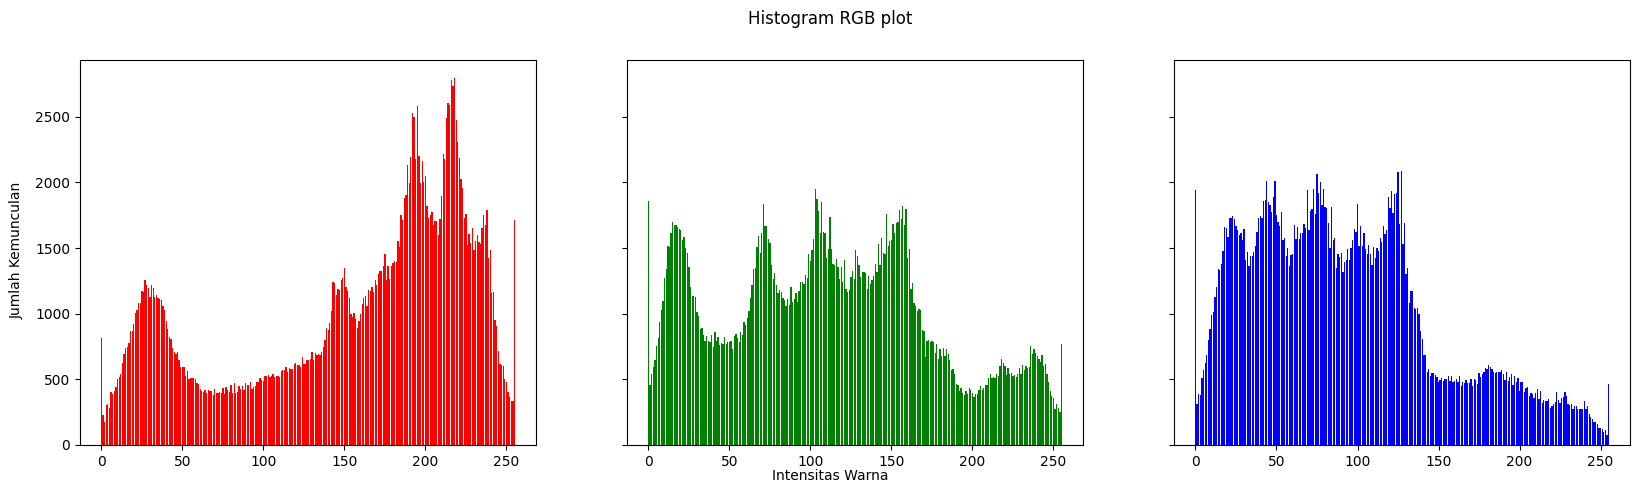

In [4]:
## E-1 No.3 — Histogram Manual (Tahap 1: lena.jpg)
img = cv.imread(CONTOH + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

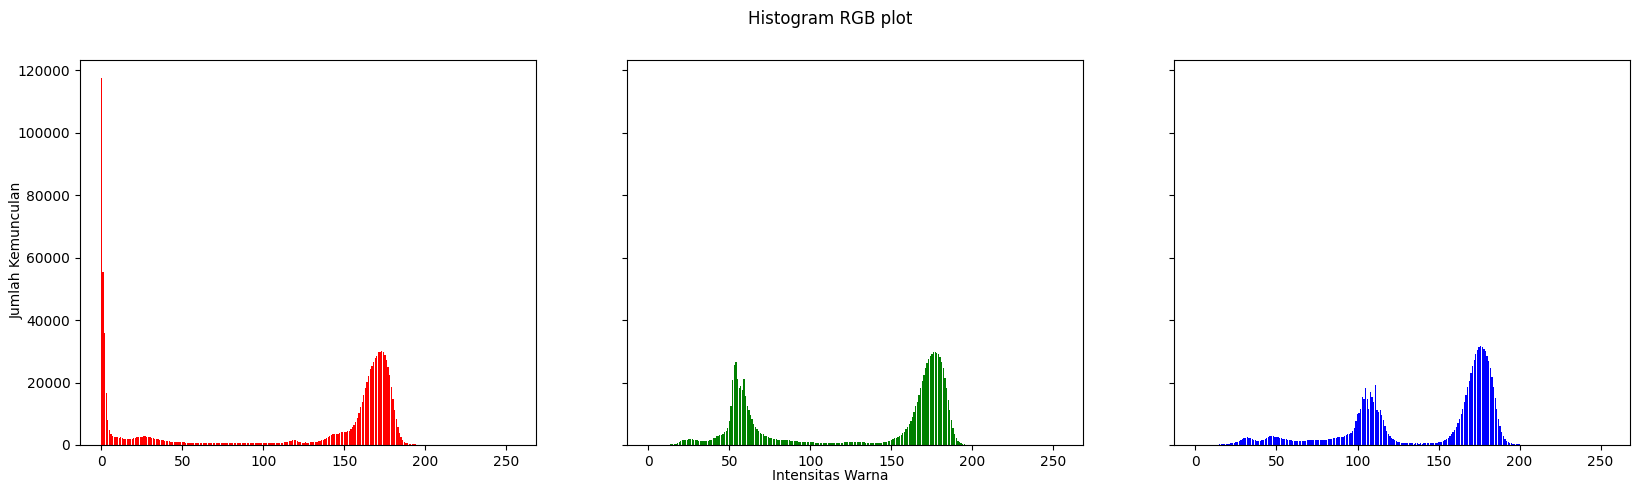

In [5]:
## E-1 No.3 — Histogram Manual (Tahap 2: KTM1b.jpg)
img = cv.imread(BASE + '/KTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

In [6]:
## E-1 Pertanyaan No.1 — Manual vs NumPy vs cv.calcHist
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def cek_selisih(nama_file):
    gray = cv.imread(nama_file, cv.IMREAD_GRAYSCALE)
    h_manual = histogram_manual(gray)
    h_numpy, _ = np.histogram(gray, bins=256, range=(0,256))
    h_cv = cv.calcHist([gray], [0], None, [256], [0,256]).flatten()

    selisih_np_manual = np.max(np.abs(h_manual - h_numpy))
    selisih_cv_manual = np.max(np.abs(h_manual - h_cv))
    print(nama_file)
    print('Selisih maksimum manual vs numpy      :', selisih_np_manual)
    print('Selisih maksimum manual vs cv.calcHist:', selisih_cv_manual)

cek_selisih(CONTOH + '/lena.jpg')
cek_selisih(BASE + '/KTM1b.jpg')

/content/drive/MyDrive/pcvk_vanesa/Images/lena.jpg
Selisih maksimum manual vs numpy      : 0
Selisih maksimum manual vs cv.calcHist: 0.0
/content/drive/MyDrive/pcvk_vanesa/Images/244107020129/KTM1b.jpg
Selisih maksimum manual vs numpy      : 0
Selisih maksimum manual vs cv.calcHist: 0.0


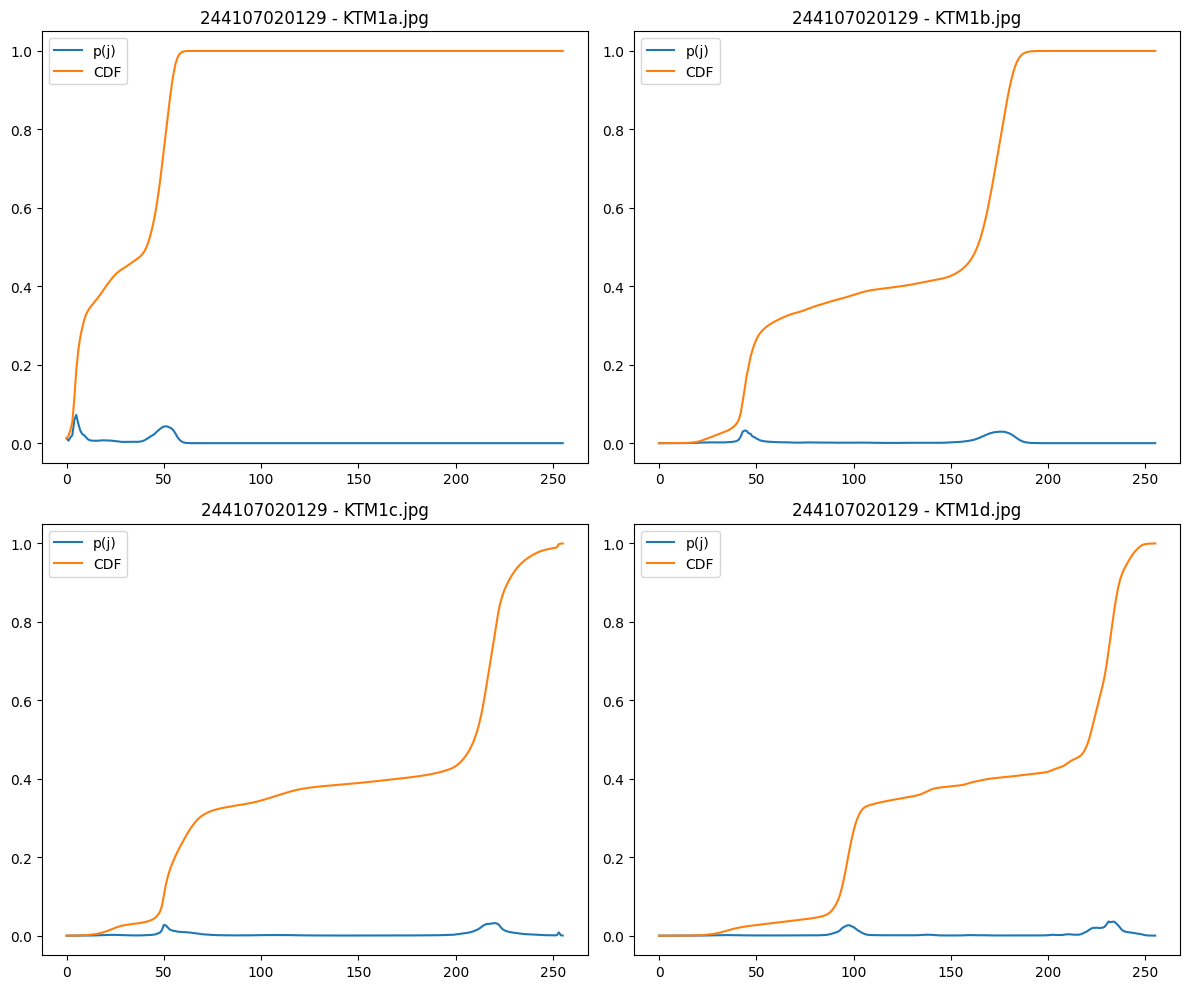

In [7]:
## E-1 Pertanyaan No.2 — p(j) dan CDF KTM1a–1d
fig, axs = plt.subplots(2, 2, figsize=(12,10))
nama_file = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']

for ax, nf in zip(axs.flat, nama_file):
    gray = cv.imread(BASE + '/' + nf, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)
    ax.plot(p, label='p(j)')
    ax.plot(cdf, label='CDF')
    ax.set_title(NIM + ' - ' + nf)
    ax.legend()

plt.tight_layout()
plt.show()

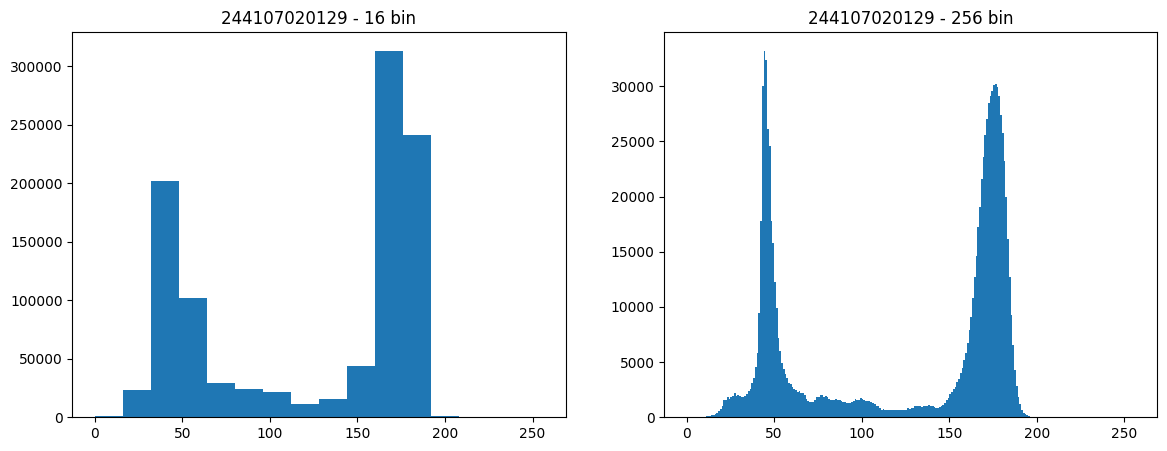

In [8]:
## E-1 Pertanyaan No.3 — Perbandingan Jumlah Bin
gray = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(14,5))
axs[0].hist(gray.ravel(), bins=PARAM['bins'], range=(0,256))
axs[0].set_title(NIM + f" - {PARAM['bins']} bin")
axs[1].hist(gray.ravel(), bins=256, range=(0,256))
axs[1].set_title(NIM + " - 256 bin")
plt.show()

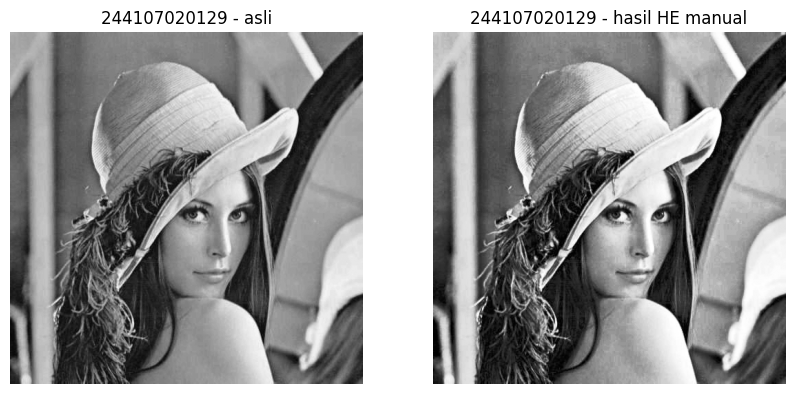

In [9]:
## E-2 Langkah 1 — Histogram Equalization Manual (Tahap 1: lena_lc.jpg)
def histogram_equalization_manual(gray):
    L = 256
    h = histogram_manual(gray, L)
    p = h / gray.size
    cdf = np.cumsum(p)
    Ko = np.round(cdf * (L - 1)).astype(np.uint8)
    hasil = Ko[gray]
    return hasil

gray = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
hasil = histogram_equalization_manual(gray)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(gray, cmap='gray'); axs[0].set_title(NIM + ' - asli'); axs[0].axis('off')
axs[1].imshow(hasil, cmap='gray'); axs[1].set_title(NIM + ' - hasil HE manual'); axs[1].axis('off')
plt.show()

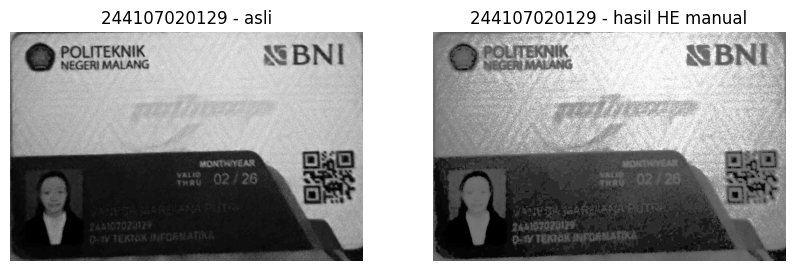

In [10]:
## E-2 Langkah 1 — Histogram Equalization Manual (Tahap 2: KTM1a.jpg)
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
hasil = histogram_equalization_manual(gray)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(gray, cmap='gray'); axs[0].set_title(NIM + ' - asli'); axs[0].axis('off')
axs[1].imshow(hasil, cmap='gray'); axs[1].set_title(NIM + ' - hasil HE manual'); axs[1].axis('off')
plt.show()

In [11]:
## E-2 Langkah 2 — Manual vs cv.equalizeHist
def bandingkan_he(nama_file):
    gray = cv.imread(nama_file, cv.IMREAD_GRAYSCALE)
    manual = histogram_equalization_manual(gray)
    cv_hasil = cv.equalizeHist(gray)
    selisih = np.max(np.abs(manual.astype(int) - cv_hasil.astype(int)))
    print(nama_file, '-> selisih maksimum:', selisih)

bandingkan_he(CONTOH + '/lena_lc.jpg')
bandingkan_he(BASE + '/KTM1a.jpg')

/content/drive/MyDrive/pcvk_vanesa/Images/lena_lc.jpg -> selisih maksimum: 0
/content/drive/MyDrive/pcvk_vanesa/Images/244107020129/KTM1a.jpg -> selisih maksimum: 4


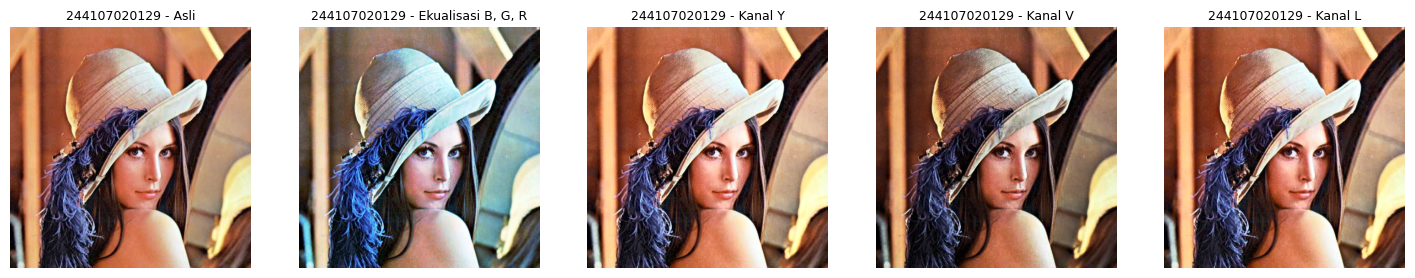

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7


In [12]:
## E-2 Langkah 3 & 4 — Ekualisasi Warna (Kanal BGR vs Y/V/L) + Pergeseran Hue
berkas = CONTOH + '/lena.jpg'   # tahap 2 ganti: BASE + '/KTM1d.jpg'
bgr    = cv.imread(berkas)

# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Kanal Y (equalizeHist)             2.66            133.5
Kanal Y (CLAHE)                    0.50            158.6


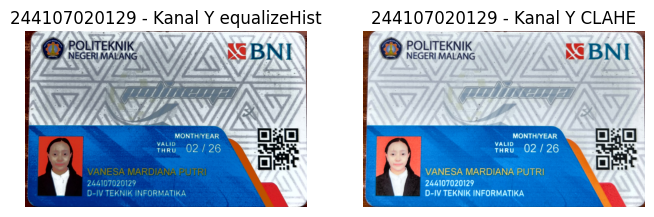

In [20]:
## E-2 Langkah 3 & 4 — Pertanyaan No.4: CLAHE pada kanal terang
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

y_clahe = clahe.apply(y)
he_y_clahe = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
print('%-22s %16.2f %16.1f' % ('Kanal Y (equalizeHist)', geser_hue(bgr, he_y) * 2,
                                cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean()))
print('%-22s %16.2f %16.1f' % ('Kanal Y (CLAHE)', geser_hue(bgr, he_y_clahe) * 2,
                                cv.cvtColor(he_y_clahe, cv.COLOR_BGR2GRAY).mean()))

fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB)); axs[0].set_title(NIM + ' - Kanal Y equalizeHist'); axs[0].axis('off')
axs[1].imshow(cv.cvtColor(he_y_clahe, cv.COLOR_BGR2RGB)); axs[1].set_title(NIM + ' - Kanal Y CLAHE'); axs[1].axis('off')
plt.show()

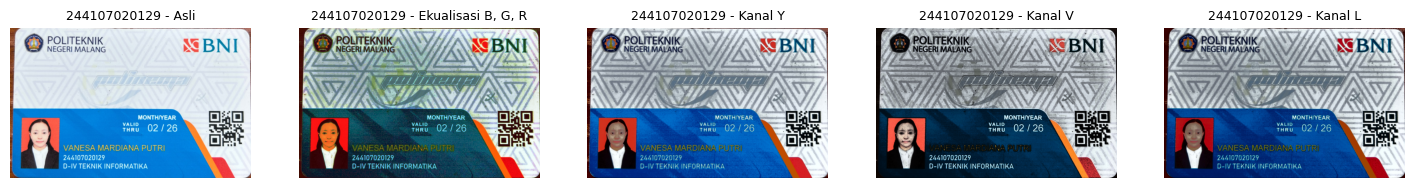

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            176.6
Ekualisasi B, G, R                32.26            125.2
Kanal Y                            2.66            133.5
Kanal V                            2.34            112.4
Kanal L                            5.14            122.9


In [21]:
## E-2 Langkah 3 & 4 — Ekualisasi Warna (Tahap 2: KTM1d.jpg)
berkas = BASE + '/KTM1d.jpg'
bgr    = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

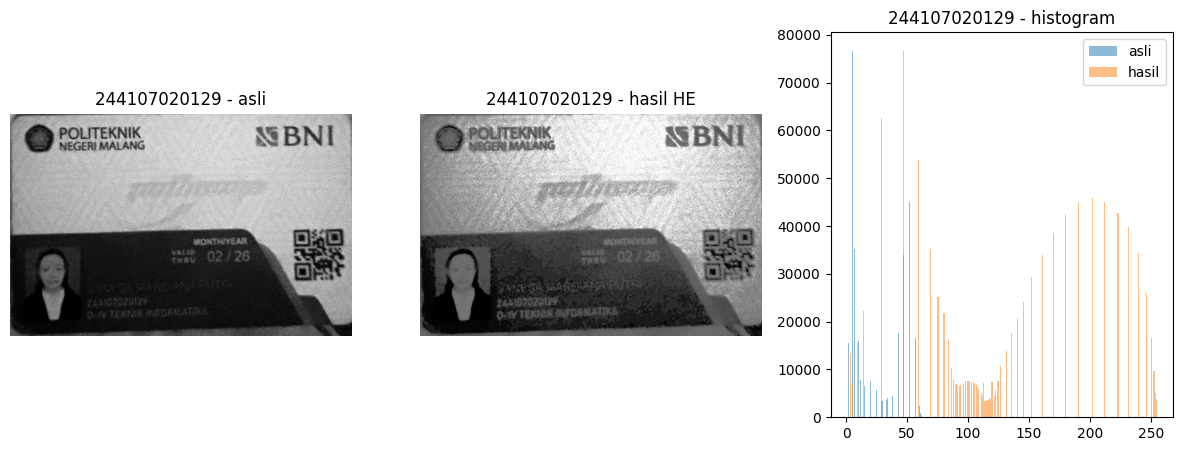

PSNR: 7.00964999231286 dB


In [22]:
## E-2 Pertanyaan No.1 — Ekualisasi Global + PSNR pada KTM1a.jpg
def hitung_psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
hasil = histogram_equalization_manual(gray)

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].imshow(gray, cmap='gray'); axs[0].set_title(NIM + ' - asli'); axs[0].axis('off')
axs[1].imshow(hasil, cmap='gray'); axs[1].set_title(NIM + ' - hasil HE'); axs[1].axis('off')
axs[2].hist(gray.ravel(), bins=256, alpha=0.5, label='asli')
axs[2].hist(hasil.ravel(), bins=256, alpha=0.5, label='hasil')
axs[2].set_title(NIM + ' - histogram'); axs[2].legend()
plt.show()

print('PSNR:', hitung_psnr(gray, hasil), 'dB')

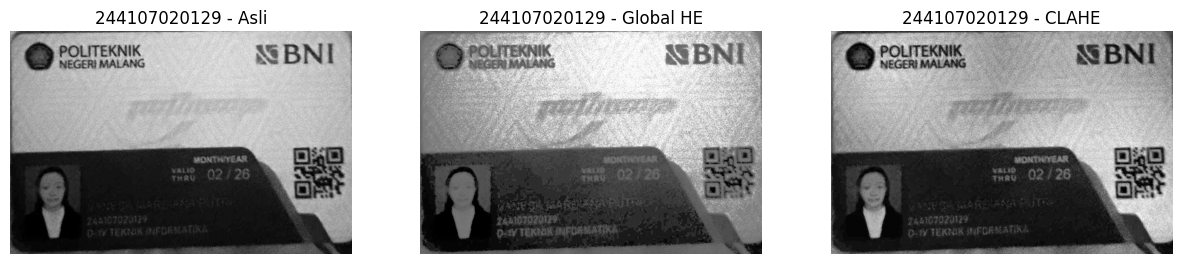

In [23]:
## E-2 Pertanyaan No.2a — CLAHE pada KTM1a.jpg
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe = clahe.apply(gray)
hasil_global = cv.equalizeHist(gray)

fig, axs = plt.subplots(1, 3, figsize=(15,5))
for ax, im, judul in zip(axs, [gray, hasil_global, hasil_clahe], ['Asli', 'Global HE', 'CLAHE']):
    ax.imshow(im, cmap='gray'); ax.set_title(NIM + ' - ' + judul); ax.axis('off')
plt.show()

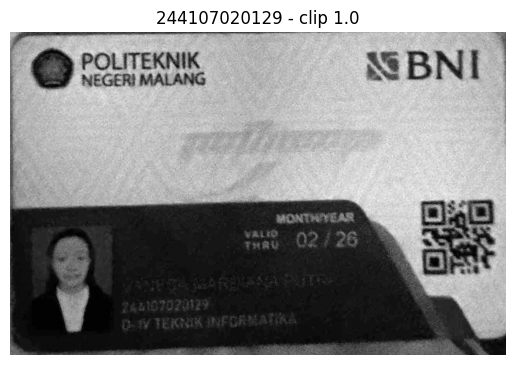

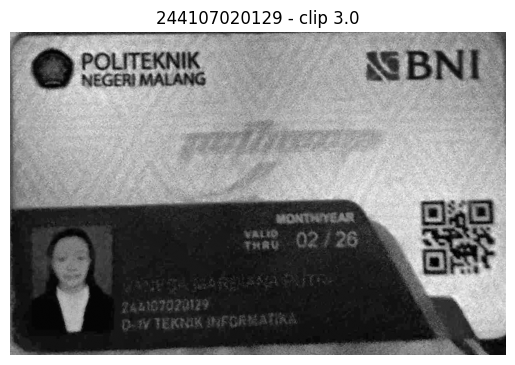

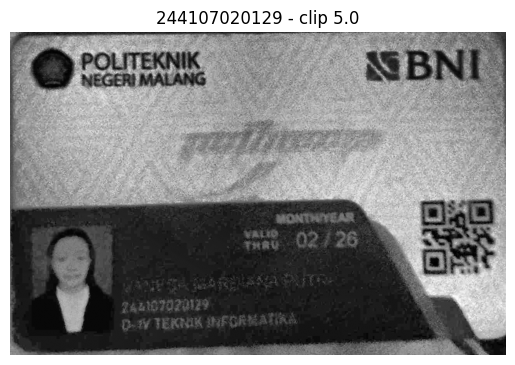

In [24]:
## E-2 Pertanyaan No.2b — Variasi clipLimit
for c in [1.0, PARAM['clip'], 5.0]:
    clahe = cv.createCLAHE(clipLimit=c, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe.apply(gray)
    plt.figure()
    plt.imshow(hasil, cmap='gray'); plt.title(NIM + f' - clip {c}'); plt.axis('off')
    plt.show()

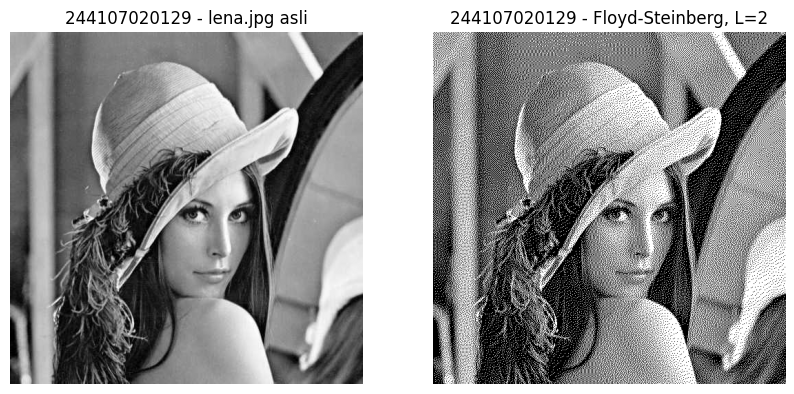

In [25]:
## E-3 Langkah 1 — Dithering Floyd-Steinberg (Tahap 1: lena.jpg)
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                     img[y,   x+1] += error * 7 / 16
            if x > 0 and y+1 < H:              img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                      img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y+1 < H:          img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

gray = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
hasil = floyd_steinberg(gray, L=2)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(gray, cmap='gray'); axs[0].set_title(NIM + ' - lena.jpg asli'); axs[0].axis('off')
axs[1].imshow(hasil, cmap='gray'); axs[1].set_title(NIM + ' - Floyd-Steinberg, L=2'); axs[1].axis('off')
plt.show()

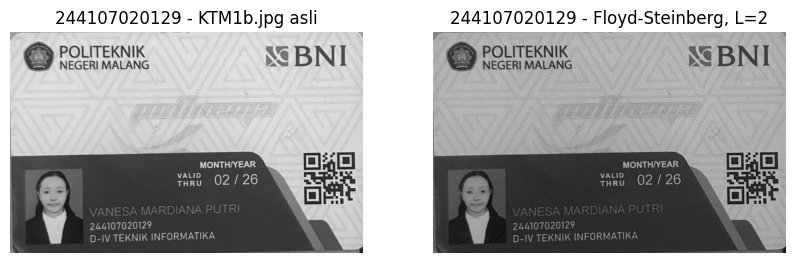

In [26]:
## E-3 Langkah 1 — Dithering Floyd-Steinberg (Tahap 2: KTM1b.jpg)
gray = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
hasil = floyd_steinberg(gray, L=PARAM['L'])

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(gray, cmap='gray'); axs[0].set_title(NIM + ' - KTM1b.jpg asli'); axs[0].axis('off')
axs[1].imshow(hasil, cmap='gray'); axs[1].set_title(NIM + f" - Floyd-Steinberg, L={PARAM['L']}"); axs[1].axis('off')
plt.show()

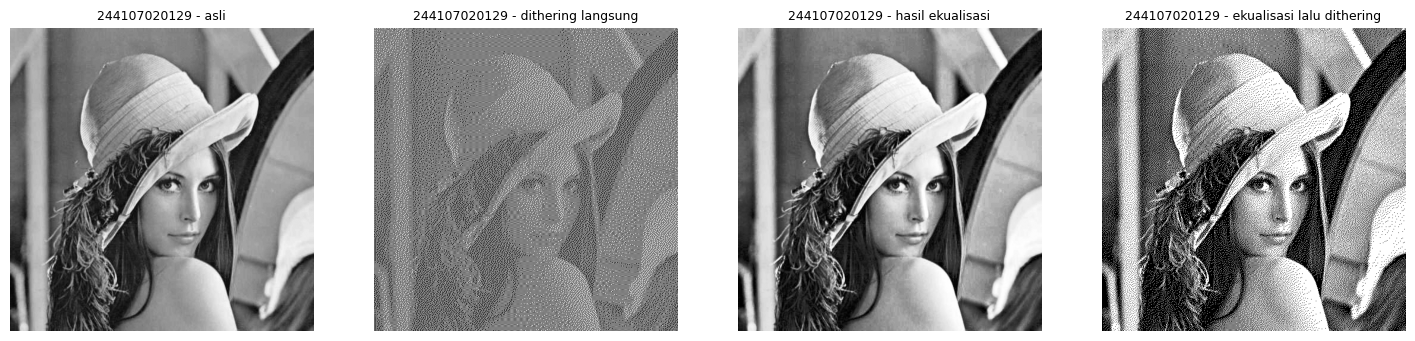

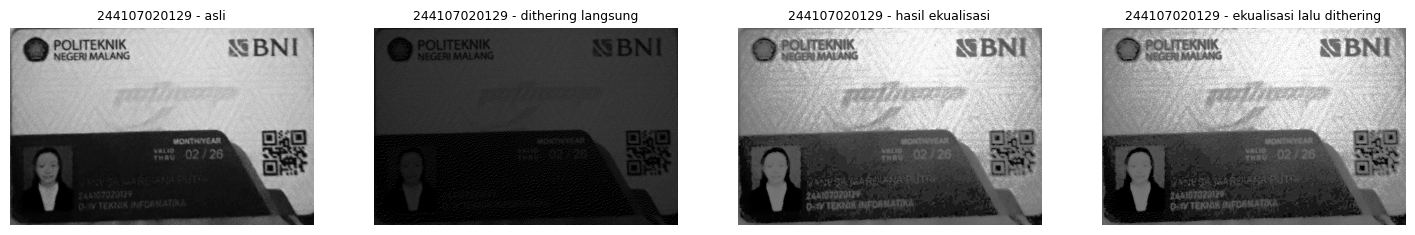

In [27]:
## E-3 Langkah 2 — Dithering Langsung vs Setelah Ekualisasi
def proses_bandingan(nama_file, L):
    gray = cv.imread(nama_file, cv.IMREAD_GRAYSCALE)
    dith_langsung = floyd_steinberg(gray, L)
    he = cv.equalizeHist(gray)
    dith_he = floyd_steinberg(he, L)

    fig, axs = plt.subplots(1, 4, figsize=(18,5))
    for ax, im, judul in zip(axs, [gray, dith_langsung, he, dith_he],
                              ['asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']):
        ax.imshow(im, cmap='gray'); ax.set_title(NIM + ' - ' + judul, fontsize=9); ax.axis('off')
    plt.show()

proses_bandingan(CONTOH + '/lena_lc.jpg', PARAM['L'])
proses_bandingan(BASE + '/KTM1a.jpg', PARAM['L'])

1. E1 No.1 — Analisis :
Berdasarkan hasil pengujian, histogram manual, NumPy, dan cv.calcHist menghasilkan nilai yang sama. Selisih maksimum antara histogram manual dengan NumPy adalah 0, sedangkan dengan cv.calcHist juga 0. Jadi, ketiga cara tersebut menghasilkan histogram yang sama dan perhitungan histogram manual sudah sesuai.
2. E1 No.2 — Analisis CDF :
Berdasarkan grafik p(j) dan CDF pada KTM1a sampai KTM1d, setiap citra memiliki bentuk distribusi intensitas yang berbeda karena kondisi pencahayaannya berbeda. KTM1a memiliki pencahayaan paling gelap sehingga sebagian besar piksel berada pada intensitas rendah. CDF-nya naik cukup cepat pada bagian intensitas rendah.
Pada KTM1d, distribusi piksel lebih banyak berada pada intensitas yang lebih tinggi karena foto diambil menggunakan cahaya matahari. Hal ini membuat CDF lebih banyak mengalami kenaikan pada bagian intensitas terang. Jadi, bentuk CDF dapat digunakan untuk melihat perbedaan tingkat pencahayaan pada saat citra diambil.
3. E1 No.3 — Analisis 16 bin vs 256 bin :
Pada histogram dengan 256 bin, distribusi intensitas terlihat lebih detail karena setiap nilai intensitas dari 0 sampai 255 dapat dilihat dengan lebih jelas. Sedangkan pada histogram 16 bin, beberapa nilai intensitas digabung ke dalam satu kelompok sehingga bentuk distribusinya menjadi lebih sederhana.
Pengurangan jumlah bin membuat detail kecil pada distribusi intensitas menjadi hilang. Namun, pola umum seperti bagian citra yang dominan gelap atau terang masih dapat terlihat.
4. E2 No.2 — Pada lena_lc.jpg : selisih maksimum antara histogram equalization manual dan cv.equalizeHist adalah 0. Artinya, hasil dari kedua metode tersebut sama.
Sedangkan pada KTM1a.jpg terdapat selisih maksimum sebesar 4. Perbedaan ini dapat terjadi karena proses pembulatan nilai hasil transformasi pada implementasi manual tidak sepenuhnya sama dengan proses yang digunakan oleh OpenCV. Walaupun terdapat selisih kecil, hasil kedua metode tetap memiliki proses dan hasil visual yang hampir sama.
5. E2 No.3 — Pertanyaan 1 : Berdasarkan hasil pengujian pada KTM1d, ekualisasi pada kanal B, G, dan R secara terpisah menghasilkan pergeseran Hue paling besar, yaitu 32,26°. Hal ini menunjukkan bahwa cara tersebut paling banyak mengubah warna asli citra.
Sementara itu, ekualisasi pada kanal Y, V, dan L menghasilkan pergeseran Hue yang jauh lebih kecil. Dari ketiga cara tersebut, kanal V memiliki pergeseran Hue sebesar 2,34°, sedangkan kanal Y sebesar 2,66° dan kanal L sebesar 5,14°.
6. E2 No.3 — Pertanyaan 2 : Ekualisasi pada kanal terang tetap menghasilkan pergeseran Hue walaupun kanal warna tidak diekualisasi secara langsung. Hal ini terjadi karena setelah proses ekualisasi, citra dikembalikan lagi ke ruang warna BGR.
Pada proses tersebut terdapat pembulatan dan pemotongan nilai piksel sehingga nilai warna hasilnya tidak selalu sama persis dengan citra awal. Karena itu, pergeseran Hue masih dapat muncul walaupun nilainya relatif kecil.
7. E2 No.3 — Pertanyaan 3 : Berdasarkan hasil pengujian pada KTM1d, kanal Y cukup sesuai digunakan untuk melakukan ekualisasi karena perubahan warnanya masih relatif kecil dengan pergeseran Hue sebesar 2,66°. Hasilnya juga masih mempertahankan warna asli KTM, sedangkan ekualisasi kanal B, G, dan R menghasilkan perubahan warna yang jauh lebih terlihat.
Pada hasil kanal Y, bagian kartu seperti foto, tulisan, logo, dan bagian berwarna masih terlihat dengan cukup jelas. Oleh karena itu, kanal Y dipilih karena dapat meningkatkan kecerahan tanpa mengubah warna citra terlalu jauh.
8. E2 No.4 — CLAHE : Berdasarkan hasil perbandingan, CLAHE memberikan perubahan kecerahan yang lebih terkontrol dibandingkan ekualisasi global. Pergeseran Hue dan nilai rerata kecerahan digunakan untuk melihat seberapa besar perubahan yang terjadi pada citra.
Dari hasil tersebut dapat dilihat bahwa metode yang menghasilkan perubahan warna lebih kecil lebih mampu mempertahankan warna asli KTM. Hasil visual juga digunakan untuk melihat apakah detail pada kartu menjadi lebih jelas setelah proses ekualisasi.
9. E2 No.1 — Analisis PSNR : Nilai PSNR antara citra asli dan hasil histogram equalization adalah sekitar 7,01 dB. Nilai ini cukup rendah karena histogram equalization memang mengubah banyak nilai piksel pada citra.
Walaupun nilai PSNR turun, hasil citra terlihat lebih jelas dibandingkan citra asli karena bagian yang sebelumnya terlalu gelap menjadi lebih terlihat. Jadi, PSNR tidak cukup digunakan untuk menentukan apakah sebuah citra lebih mudah dibaca atau tidak, karena PSNR lebih menunjukkan seberapa besar perubahan piksel dari citra asli.
10. E2 No.2a — Global HE vs CLAHE : Berdasarkan hasil perbandingan, citra hasil CLAHE memiliki detail pada bagian kartu yang lebih terlihat dibandingkan citra asli. Bagian nama, NIM, dan informasi pada kartu menjadi lebih mudah dibedakan dari background.
Ekualisasi global juga meningkatkan kontras, tetapi perubahan terjadi pada keseluruhan citra. Pada CLAHE, peningkatan kontras dilakukan secara lokal sehingga bagian yang gelap tetap dapat ditingkatkan tanpa terlalu mengubah seluruh citra. Oleh karena itu, CLAHE lebih membantu untuk melihat tulisan pada bagian kartu yang gelap.
11. E2 No.2b — Analisis clipLimit : Pada percobaan ini digunakan beberapa nilai clipLimit, yaitu 1.0, 3.0, dan 5.0. Perubahan nilai clipLimit memengaruhi tingkat peningkatan kontras pada citra.
Pada clipLimit yang lebih rendah, peningkatan kontras terlihat lebih ringan. Ketika nilai clipLimit dinaikkan, kontras menjadi lebih kuat dan detail pada bagian tertentu lebih terlihat. Namun, peningkatan yang terlalu besar juga dapat membuat noise pada citra menjadi lebih terlihat.
Dari hasil percobaan, nilai clipLimit 3.0 dapat digunakan karena sudah memberikan peningkatan kontras yang cukup tanpa perubahan yang terlalu berlebihan.
12. E3 No.2 — Analisis Dithering : Pada citra KTM1a, dithering yang dilakukan langsung menghasilkan citra yang cukup gelap sehingga beberapa tulisan pada kartu sulit dibaca. Setelah dilakukan histogram equalization terlebih dahulu, distribusi intensitas citra menjadi lebih baik sebelum masuk ke proses dithering.
Hasil ekualisasi kemudian dithering menunjukkan bagian tulisan dan detail kartu lebih terlihat dibandingkan dithering yang dilakukan langsung. Jadi, pada KTM1a urutan ekualisasi terlebih dahulu kemudian dithering menghasilkan hasil yang lebih mudah dibaca.